In [3]:
# Load Libraries
import pandas as pd
import numpy as np
import seaborn as sns
import sklearn
import altair as alt
import matplotlib.pyplot as plt

In [ ]:
# Load People.csv, FieldingPost.csv, PitchingPost.csv, BattingPost.csv, Schools.csv, Salaries.csv, Appearances.csv, HallOfFame.csvf
DATA_PATH = "baseball/core/"
ppl  = pd.read_csv(DATA_PATH + "People.csv")
fld  = pd.read_csv(DATA_PATH + "FieldingPost.csv")
pch  = pd.read_csv(DATA_PATH + "PitchingPost.csv")DATA_PATH
bat  = pd.read_csv(DATA_PATH + "BattingPost.csv")
scl  = pd.read_csv(DATA_PATH + "Schools.csv")
sal  = pd.read_csv(DATA_PATH + "Salaries.csv")
hof  = pd.read_csv(DATA_PATH + "HallOfFame.csv")
app  = pd.read_csv(DATA_PATH + "Appearances.csv")
inf  = pd.read_csv("baseball/infCoef.csv")

In [5]:
# Check the datasets
print("People:", ppl.shape)
print("Salaries:", sal.shape)
print("Hall of Fame:", hof.shape)
print("Appearances:", app.shape)

People: (19370, 24)
Salaries: (26428, 5)
Hall of Fame: (4191, 9)
Appearances: (104256, 21)


In [6]:
print("People columns")
print(ppl.columns.tolist())

print("\nSalary columns:")
print(sal.columns.tolist())

print("\nHall of Fame columns:")
print(hof.columns.tolist())

print("\nAppearance columns:")
print(app.columns.tolist())

People columns
['playerID', 'birthYear', 'birthMonth', 'birthDay', 'birthCountry', 'birthState', 'birthCity', 'deathYear', 'deathMonth', 'deathDay', 'deathCountry', 'deathState', 'deathCity', 'nameFirst', 'nameLast', 'nameGiven', 'weight', 'height', 'bats', 'throws', 'debut', 'finalGame', 'retroID', 'bbrefID']

Salary columns:
['yearID', 'teamID', 'lgID', 'playerID', 'salary']

Hall of Fame columns:
['playerID', 'yearid', 'votedBy', 'ballots', 'needed', 'votes', 'inducted', 'category', 'needed_note']

Appearance columns:
['yearID', 'teamID', 'lgID', 'playerID', 'G_all', 'GS', 'G_batting', 'G_defense', 'G_p', 'G_c', 'G_1b', 'G_2b', 'G_3b', 'G_ss', 'G_lf', 'G_cf', 'G_rf', 'G_of', 'G_dh', 'G_ph', 'G_pr']


In [7]:
# ----------------------------------
# Analysis of Hall of Fame vs Salary
# ----------------------------------

# Particularly, is Hall of Fame membership associated with higher career salary among MLB players?
# Does the relationship remain when noting total seasons played?

In [8]:
# We need to account for inflation in all salary calculations

salInf = sal.merge(
    inf,
    left_on="yearID",
    right_on="yearID",
    how="left"
)
display(salInf.head())
print("Missing inflation coefficients:", salInf["coefficient"].isna().sum())
salInf["salaryAdjusted"] = (
    salInf["salary"] * salInf["coefficient"]
)
display(
    salInf[
        ["playerID", "yearID", "salary", "coefficient", "salaryAdjusted"]
    ].head(20)
)

,yearID,teamID,lgID,playerID,salary,coefficient
0,1985,ATL,NL,barkele01,870000,2.4063
1,1985,ATL,NL,bedrost01,550000,2.4063
2,1985,ATL,NL,benedbr01,545000,2.4063
3,1985,ATL,NL,campri01,633333,2.4063
4,1985,ATL,NL,ceronri01,625000,2.4063


Missing inflation coefficients: 0


,playerID,yearID,salary,coefficient,salaryAdjusted
0,barkele01,1985,870000,2.4063,2.093481e+06
1,bedrost01,1985,550000,2.4063,1.323465e+06
2,benedbr01,1985,545000,2.4063,1.311434e+06
3,campri01,1985,633333,2.4063,1.523989e+06
4,ceronri01,1985,625000,2.4063,1.503938e+06
5,chambch01,1985,800000,2.4063,1.925040e+06
6,dedmoje01,1985,150000,2.4063,3.609450e+05
7,forstte01,1985,483333,2.4063,1.163044e+06
8,garbege01,1985,772000,2.4063,1.857664e+06
9,harpete01,1985,250000,2.4063,6.015750e+05


In [9]:
# Identifying Hall of Fame players
hofPlayers = hof[hof["inducted"] == "Y"][["playerID"]].drop_duplicates()
print("Number of Hall of Fame players:", len(hofPlayers))
display(hofPlayers.head())

Number of Hall of Fame players: 323


,playerID
0,cobbty01
1,ruthba01
2,wagneho01
3,mathech01
4,johnswa01


In [10]:
# Lets check the salaries of the Hall of Famers

salaryHOF = salInf.merge(
    hofPlayers.assign(hallOfFame=True),
    on="playerID",
    how="left"
)
salaryHOF["hallOfFame"] = salaryHOF["hallOfFame"].fillna(False)
display(salaryHOF.head())

,yearID,teamID,lgID,playerID,salary,coefficient,salaryAdjusted,hallOfFame
0,1985,ATL,NL,barkele01,870000,2.4063,2.093481e+06,False
1,1985,ATL,NL,bedrost01,550000,2.4063,1.323465e+06,False
2,1985,ATL,NL,benedbr01,545000,2.4063,1.311434e+06,False
3,1985,ATL,NL,campri01,633333,2.4063,1.523989e+06,False
4,1985,ATL,NL,ceronri01,625000,2.4063,1.503938e+06,False


In [11]:
# Calculate the total salary recorded

careerSalary = (
    salaryHOF
    .groupby(["playerID", "hallOfFame"], as_index=False)
    .agg(
        careerSalary=("salaryAdjusted", "sum"),
        averageSalary=("salaryAdjusted", "mean"),
        seasonsPaid=("yearID", "nunique")
    )
)

print("Rows to compare:", len(careerSalary))
careerSalary = careerSalary.merge(
    ppl[["playerID", "nameFirst", "nameLast"]],
    on="playerID",
    how="left"
)
careerSalary["name"] = (
    careerSalary["nameFirst"] + " " + careerSalary["nameLast"]
)
display(careerSalary.head())

Rows to compare: 5149


,playerID,hallOfFame,careerSalary,averageSalary,seasonsPaid,nameFirst,nameLast,name
0,aardsda01,False,10888994.95,1.555571e+06,7,David,Aardsma,David Aardsma
1,aasedo01,False,5152505.00,1.288126e+06,4,Don,Aase,Don Aase
2,abadan01,False,419802.60,4.198026e+05,1,Andy,Abad,Andy Abad
3,abadfe01,False,4137729.08,8.275458e+05,5,Fernando,Abad,Fernando Abad
4,abbotje01,False,1495701.50,3.739254e+05,4,Jeff,Abbott,Jeff Abbott


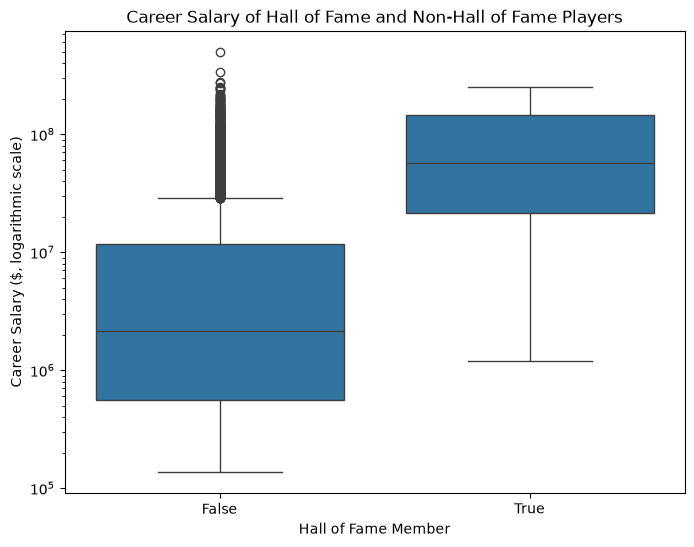

In [12]:
# Lets compare the groups
careerSalary.groupby("hallOfFame")[
    ["careerSalary", "averageSalary", "seasonsPaid"]
    ].median()

plt.figure(figsize=(8, 6))
sns.boxplot(
    data=careerSalary,
    x="hallOfFame",
    y="careerSalary"
)

plt.yscale("log")
plt.title("Career Salary of Hall of Fame and Non-Hall of Fame Players")
plt.xlabel("Hall of Fame Member")
plt.ylabel("Career Salary ($, logarithmic scale)")
plt.show()

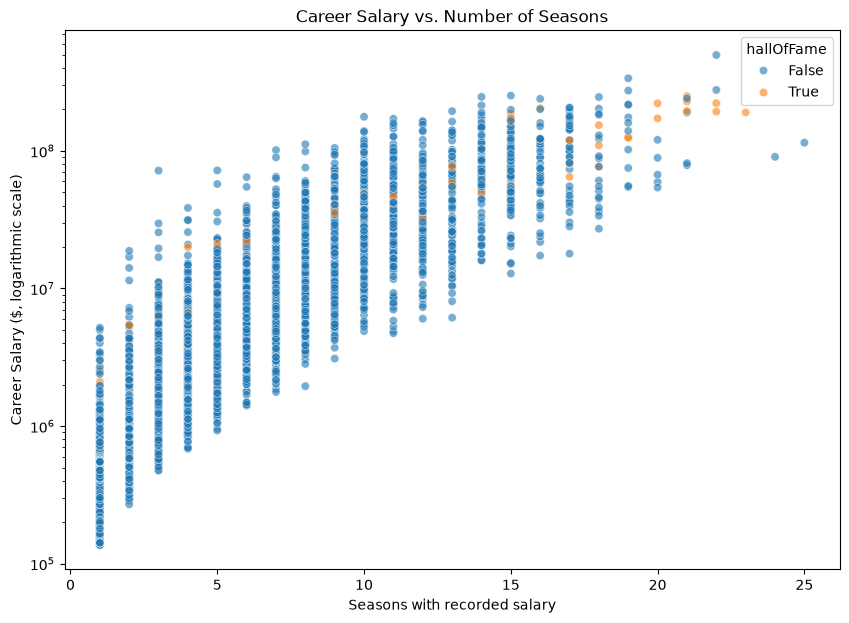

In [13]:
# The above graph shouldn't be all that surprising, so let's see if it's because they play longer or they actually command higher salaries

plt.figure(figsize=(10,7))
sns.scatterplot(
    data=careerSalary,
    x="seasonsPaid",
    y="careerSalary",
    hue="hallOfFame",
    alpha=0.6
)
plt.yscale("log")
plt.title("Career Salary vs. Number of Seasons")
plt.xlabel("Seasons with recorded salary")
plt.ylabel("Career Salary ($, logarithmic scale)")
plt.show()

In [14]:
# ---------------------------------
# Analysis of Appearances vs Salary
# ---------------------------------

# Particularly, what is the relationship between player appearances and salary?
# Are there any players who earned unusually high salaries relative to their playing time?

In [15]:
# Remembering that the column G_all notes total games played, we can see how many career appearances each player has made
careerAppearances = (
    app
    .groupby("playerID", as_index=False)
    .agg(
        careerGames=("G_all", "sum"),
        seasonsPlayed=("yearID", "nunique")
    )
)

display(careerAppearances.head())

,playerID,careerGames,seasonsPlayed
0,aardsda01,331,9
1,aaronha01,3298,23
2,aaronto01,437,7
3,aasedo01,448,13
4,abadan01,15,3


In [16]:
# Lets combine salary and appearances
salaryGames = careerSalary.merge(
    careerAppearances,
    on="playerID",
    how="inner"
)

display(salaryGames.head())

,playerID,hallOfFame,careerSalary,averageSalary,seasonsPaid,nameFirst,nameLast,name,careerGames,seasonsPlayed
0,aardsda01,False,10888994.95,1.555571e+06,7,David,Aardsma,David Aardsma,331,9
1,aasedo01,False,5152505.00,1.288126e+06,4,Don,Aase,Don Aase,448,13
2,abadan01,False,419802.60,4.198026e+05,1,Andy,Abad,Andy Abad,15,3
3,abadfe01,False,4137729.08,8.275458e+05,5,Fernando,Abad,Fernando Abad,363,8
4,abbotje01,False,1495701.50,3.739254e+05,4,Jeff,Abbott,Jeff Abbott,233,5


In [17]:
# Salary per game analysis
salaryGames["salaryPerGame"] = (
    salaryGames["careerSalary"] / salaryGames["careerGames"]
)
salaryGames.sort_values(
    "salaryPerGame",
    ascending=False
)[
    [
        "name",
        "careerSalary",
        "careerGames",
        "salaryPerGame",
    ]
].head(20)

,name,careerSalary,careerGames,salaryPerGame
757,Chris Carpenter,1.694738e+07,18,941520.878400
4555,Masahiro Tanaka,7.179260e+07,105,683739.047619
1730,Miguel Gonzalez,4.008400e+06,6,668066.727400
3502,Christian Parker,6.068635e+05,1,606863.540000
2208,Chad Hutchinson,1.717380e+06,3,572460.000000
4102,CC Sabathia,2.516621e+08,510,493455.011398
2530,Hiroki Kuroda,1.012140e+08,212,477424.360179
4715,Matt Tupman,4.687800e+05,1,468780.000000
1594,Anderson Garcia,4.687800e+05,1,468780.000000
1873,Roy Halladay,1.800773e+08,416,432878.102611


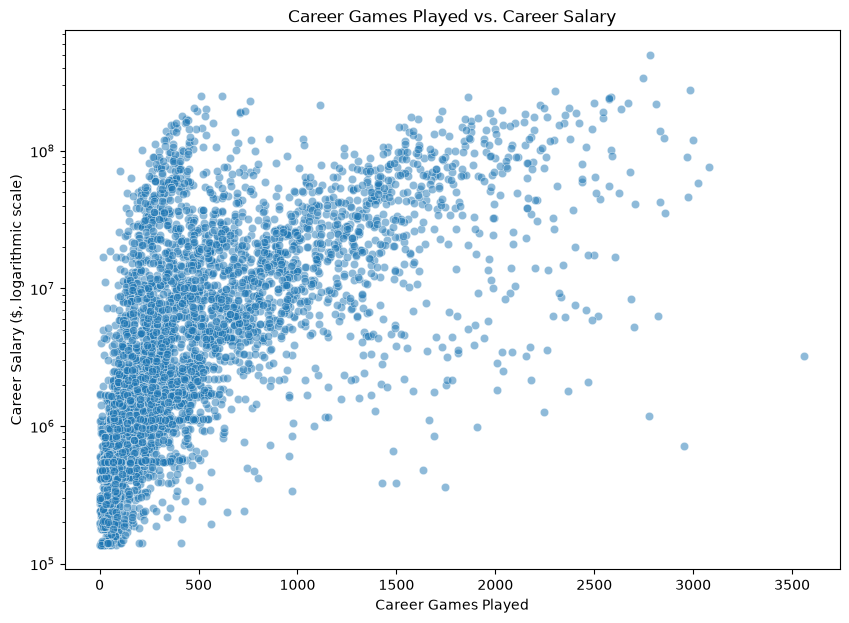

In [18]:
# We will note some immediate outliers in the data, particularly the people with single digit games played.
# Injuries, releases, steroid use, and other weird seasons may create interesting outliers.
# We will keep these in mind as we make a general scatterplot for this.

plt.figure(figsize=(10,7))
sns.scatterplot(
    data=salaryGames,
    x="careerGames",
    y="careerSalary",
    alpha=0.5
)
plt.yscale("log")
plt.title("Career Games Played vs. Career Salary")
plt.xlabel("Career Games Played")
plt.ylabel("Career Salary ($, logarithmic scale)")
plt.show()

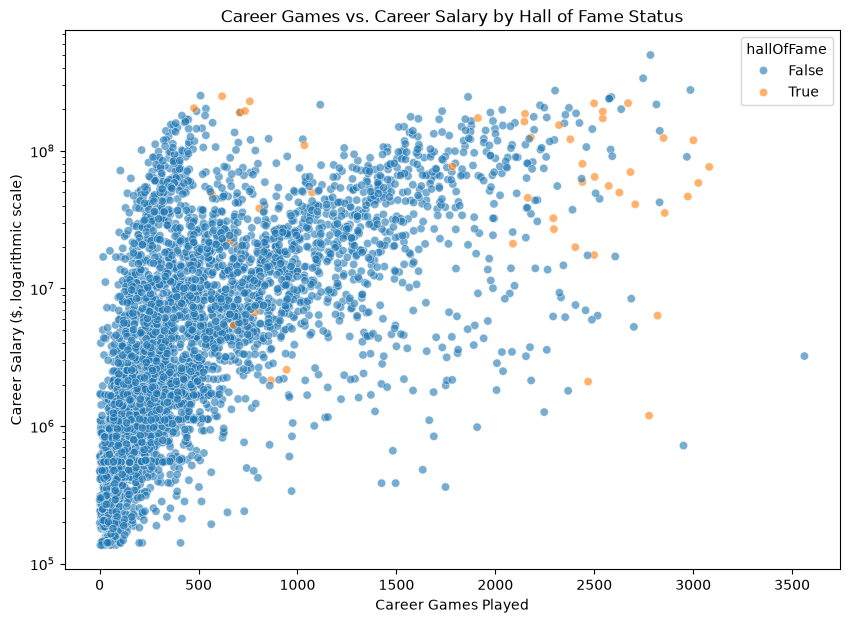

In [19]:
# For fun, let's connect the Hall of Fame status
plt.figure(figsize=(10,7))
sns.scatterplot(
    data=salaryGames,
    x="careerGames",
    y="careerSalary",
    hue="hallOfFame",
    alpha=0.6
)

plt.yscale("log")
plt.title("Career Games vs. Career Salary by Hall of Fame Status")
plt.xlabel("Career Games Played")
plt.ylabel("Career Salary ($, logarithmic scale)")
plt.show()

,name,careerGames,careerSalary,salaryPerGame,salaryResidual
4102,CC Sabathia,510,2.516621e+08,493455.011398,4.340195
1873,Roy Halladay,416,1.800773e+08,432878.102611,4.218803
2882,Pedro Martinez,477,2.040343e+08,427744.776011,4.205281
4166,Johan Santana,360,1.551120e+08,430866.714468,4.196642
4802,Justin Verlander,385,1.588639e+08,412633.583117,4.163812
2030,Felix Hernandez,375,1.532531e+08,408674.805786,4.150546
295,Josh Beckett,335,1.395276e+08,416500.321076,4.147488
578,Kevin Brown,490,1.939751e+08,395867.592133,4.125223
640,A. J. Burnett,436,1.695343e+08,388840.050344,4.113087
2530,Hiroki Kuroda,212,1.012140e+08,477424.360179,4.105580


,playerID,hallOfFame,careerSalary,averageSalary,seasonsPaid,nameFirst,nameLast,name,careerGames,seasonsPlayed,salaryPerGame,predictedLogSalary,salaryResidual
4102,sabatcc01,False,2.516621e+08,1.677747e+07,15,CC,Sabathia,CC Sabathia,510,17,493455.011398,15.003403,4.340195
1873,hallaro01,False,1.800773e+08,1.286266e+07,14,Roy,Halladay,Roy Halladay,416,16,432878.102611,14.790094,4.218803
2882,martipe02,True,2.040343e+08,1.275214e+07,16,Pedro,Martinez,Pedro Martinez,477,18,427744.776011,14.928517,4.205281
4166,santajo01,False,1.551120e+08,1.292600e+07,12,Johan,Santana,Johan Santana,360,12,430866.714468,14.663016,4.196642
4802,verlaju01,False,1.588639e+08,1.444218e+07,11,Justin,Verlander,Justin Verlander,385,13,412633.583117,14.719747,4.163812
2030,hernafe02,False,1.532531e+08,1.393210e+07,11,Felix,Hernandez,Felix Hernandez,375,13,408674.805786,14.697055,4.150546
295,beckejo02,False,1.395276e+08,1.073289e+07,13,Josh,Beckett,Josh Beckett,335,14,416500.321076,14.606285,4.147488
578,brownke01,False,1.939751e+08,1.141030e+07,17,Kevin,Brown,Kevin Brown,490,19,395867.592133,14.958018,4.125223
640,burneaj01,False,1.695343e+08,9.972604e+06,17,A. J.,Burnett,A. J. Burnett,436,17,388840.050344,14.835478,4.113087
2530,kurodhi01,False,1.012140e+08,1.445914e+07,7,Hiroki,Kuroda,Hiroki Kuroda,212,7,477424.360179,14.327168,4.105580


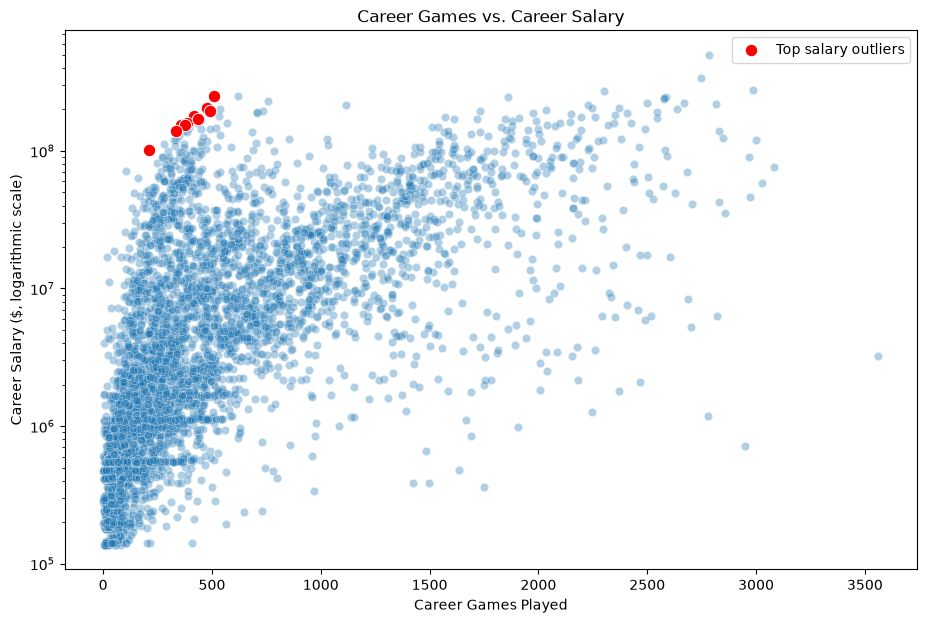

In [ ]:
# Noting the above, we can use linear regression to find out who made a lot more money than expected given their career number of games.

from sklearn.linear_model import LinearRegression

# Using log salary because salaries are heavily skewedDATA_PATH
X = salaryGames[["careerGames"]]
y = np.log1p(salaryGames["careerSalary"])

model = LinearRegression()
model.fit(X,y)

salaryGames["predictedLogSalary"] = model.predict(X)

salaryGames["salaryResidual"] = (
    y - salaryGames["predictedLogSalary"]
)

outliers = salaryGames.sort_values(
    "salaryResidual",
    ascending=False
)

display(
    outliers[
        [
            "name",
            "careerGames",
            "careerSalary",
            "salaryPerGame",
            "salaryResidual"
        ]
    ].head(20)
)

plt.figure(figsize=(11,7))

sns.scatterplot(
    data=salaryGames,
    x="careerGames",
    y="careerSalary",
    alpha=0.35
)
topOutliers = salaryGames.nlargest(10, "salaryResidual")
display(topOutliers)
sns.scatterplot(
    data=topOutliers,
    x="careerGames",
    y="careerSalary",
    color="red",
    s=80,
    label="Top salary outliers"
)

plt.yscale("log")
plt.title("Career Games vs. Career Salary")
plt.xlabel("Career Games Played")
plt.ylabel("Career Salary ($, logarithmic scale)")
plt.legend()
plt.show()

In [ ]:
# Load People.csv, FieldingPost.csv, PitchingPost.csv, BattingPost.csv, Schools.csv, Salaries.csv, etc.
DATA_PATH = "baseball/core/"
ppl  = pd.read_csv(DATA_PATH + "People.csv")
fld  = pd.read_csv(DATA_PATH + "FieldingPost.csv")
pch  = pd.read_csv(DATA_PATH + "PitchingPost.csv")
bat  = pd.read_csv(DATA_PATH + "BattingPost.csv")
scl  = pd.read_csv(DATA_PATH + "Schools.csv")
sal  = pd.read_csv(DATA_PATH + "Salaries.csv")
col  = pd.read_csv(DATA_PATH + "CollegePlaying.csv")
infCoef = pd.read_csv("baseball/infCoef.csv")

In [ ]:
# "Clean" data
fld.drop(['CS','SB','PB'], axis="columns", inplace=True)
ppl.drop(['birthMonth','birthDay','birthCountry',
       'birthState','birthCity','deathYear','deathMonth','deathDay',
       'deathCountry','deathState','deathCity'], axis="columns", inplace=True)
ppl['finalGame'] = ppl.finalGame.astype('datetime64[ns]')
ppl = ppl[ppl.finalGame.dt.year > 1900] # modern baseball rules established in 1901
sal = sal[sal.yearID > 1900]

# Join data
college = col.merge(scl, on='schoolID', how='left').iloc[:, :-1]

# Apply coef on everyones salary
sal = sal.merge(infCoef, on="yearID", how="left")
sal["finalSalary"] = sal.coefficient * sal.salary

In [ ]:
last_college = college.groupby('playerID').max()
last_college.reset_index(inplace=True)
last_college = last_college[last_college.yearID > 1984]

In [ ]:
sorta_ivy = ['Brown University', 'Columbia University', 'Cornell University',
             'Dartmouth College', 'Harvard University', 'University of Pennsylvania',
             'Princeton University', 'Yale University', 'Northwestern University',
             'University of Notre Dame', 'Georgetown University',
             'Johns Hopkins University', 'University of Chicago', 'Tufts University',
             'Massachusetts Institute of Technology']  

sporty = ['University of Southern California', 'Louisiana State University', 'Texas A&M University',
          'University of Texas at Austin', 'University of Arizona', 'Arizona State University',
          'University of Oklahoma', 'Oklahoma State University', 'University of Miami', 'Florida State University',
          'University of Florida', 'University of Georgia', 'Mississippi State University', 'University of Mississippi',
          'Auburn University', 'University of South Carolina', 'Clemson University',
          'University of California, Los Angeles',
          'California State University Fullerton', 'California State University Long Beach',
          'California State University Fresno',
          'Wichita State University', 'Pepperdine University', 'Baylor University',
          'University of North Carolina at Chapel Hill', 'Oregon State University', 'Coastal Carolina University',
          'Stanford University', 'Vanderbilt University', 'Duke University', 'Rice University']

last_college = last_college.assign(
    school_type = lambda x: np.select(
        [x.name_full.isin(sorta_ivy), x.name_full.isin(sporty)],
        [1, 2],
        default=0
    )
)

In [ ]:
player_salary = sal.groupby("playerID").agg(
    career_total = ("finalSalary", "sum"),
    peak_salary  = ("finalSalary", "max"),
    avg_salary   = ("finalSalary", "mean"),
    years_played = ("finalSalary", "count")
).reset_index()

analysis_df = player_salary.merge(
    last_college[["playerID", "school_type"]],
    on="playerID", how="inner"
)

label_map = {0: "Others", 1: "Academics", 2: "Sport Schools"}
analysis_df["school_type_label"] = analysis_df["school_type"].map(label_map)

In [ ]:
avg_chart = alt.Chart(analysis_df).mark_boxplot().encode(
    x=alt.X("school_type_label:N", title="School Type", sort=["Others", "Academics", "Sport Schools"]),
    y=alt.Y(
        "avg_salary:Q",
        scale=alt.Scale(type="log"),
        axis=alt.Axis(format="$,.0f", title="Career Average Salary ($, log scale)")
    )
).properties(
    width=200,
    title='How Well Were Players Paid Across Career?'
)

peak_chart = alt.Chart(analysis_df).mark_boxplot().encode(
    x=alt.X("school_type_label:N", title="School Type", sort=["Others", "Academics", "Sport Schools"]),
    y=alt.Y(
        "peak_salary:Q",
        scale=alt.Scale(type="log"),
        axis=alt.Axis(format="$,.0f", title="Career Peak Salary ($, log scale)")
    )
).properties(
    width=200,
    title='How Well Were Players Paid At Their Best?'
)

years_chart = alt.Chart(analysis_df).mark_boxplot().encode(
    x=alt.X("school_type_label:N", title="School Type", sort=["Others", "Academics", "Sport Schools"]),
    y=alt.Y(
        "years_played:Q",
        axis=alt.Axis(title="Career Years Played")
    )
).properties(
    width=200,
    title='How Long Did Players Play?'
)

combined_chart = avg_chart | peak_chart | years_chart
combined_chart

In [ ]:
# Look at salary over time 
stat_sal = pd.DataFrame()

# Take the summary stats
stat_sal['Mean']          = sal.groupby("yearID")["finalSalary"].mean()
stat_sal['Median']        = sal.groupby("yearID")["finalSalary"].median()
stat_sal['.25 Quartile']  = sal.groupby("yearID")["finalSalary"].quantile(0.25)
stat_sal['.75 Quartile']  = sal.groupby("yearID")["finalSalary"].quantile(0.75)
stat_sal.reset_index(inplace=True)
stat_sal = stat_sal.melt(id_vars="yearID")

# NOTE: Salary only starts at 1985 (womp-womp)

# Plot trend
sal_chart = alt.Chart(stat_sal).mark_line(interpolate="monotone").encode(
    x=alt.X(
        "yearID:Q",
        title='Year',
        axis=alt.Axis(labelAngle=-45, format='d'),
        scale=alt.Scale(domain=[1985, stat_sal.yearID.max()])
    ),
    y=alt.Y(
        "value:Q",
        title='Salary ($)',
        axis=alt.Axis(format='$,.0f')
        ),
    color=alt.Color(
    "variable:N",
    sort=["Mean", "Median", ".25 Quartile", ".75 Quartile"],
    legend=alt.Legend(title='Summary Stat.')
    )
).properties(
    title={
        'text':'MLB Players Salary Trends',
        'subtitle':'Salaries are rising'
    }
)

sal_chart = sal_chart.configure_title(
    fontSize=18,
    anchor='start'
)

In [ ]:
sal_chart.show()